In [2]:
%matplotlib inline

import gym
import matplotlib
import numpy as np
import sys

from collections import defaultdict

if "../" not in sys.path:
  sys.path.append("../") 
from lib.envs.blackjack import BlackjackEnv
from lib import plotting

matplotlib.style.use('ggplot')

In [3]:
env = BlackjackEnv()

In [ ]:
import time
def mc_prediction(policy, env, num_episodes, discount_factor=1.0):
    """
    Monte Carlo prediction algorithm. Calculates the value function
    for a given policy using sampling.
    
    Args:
        policy: A function that maps an observation to action probabilities.
        env: OpenAI gym environment.
        num_episodes: Number of episodes to sample.
        discount_factor: Gamma discount factor.
    
    Returns:
        A dictionary that maps from state -> value.
        The state is a tuple and the value is a float.
    """

    # Keeps track of sum and count of returns for each state
    # to calculate an average. We could use an array to save all
    # returns (like in the book) but that's memory inefficient.
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    
    # The final value function
    V = defaultdict(float)
    method_1_time = 0
    method_2_time = 0
    for i_episode in range(1, num_episodes + 1):
        # Print out which episode we're on, useful for debugging.
        if i_episode % 10000 == 0:
            print("\rEpisode {}/{}.".format(i_episode, num_episodes), end="")
            sys.stdout.flush()
        
        episode = []
        # map (first_state,idx_in_episode)
        first_state_indices = {}
        state = env.reset()
        for t in range(100):
            # 按策略执行动作
            action = policy(state)
            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            if state not in first_state_indices:
                first_state_indices[state] = t
            if done:
                break
            state = next_state
        
        # first-visit MC
        # 写法1: 计算每个状态的回报
        # start = time.perf_counter()
        # for s, idx in first_state_indices.items():
        #     # 每个状态会重复计算G的共有部分
        #     G = sum(x[2] * (discount_factor ** i) for i, x in enumerate(episode[idx:]))  #这种写法会新建listepisode[idx:],性能较差
        #     returns_sum[s] += G
        #     returns_count[s] += 1.0
        #     V[s] = returns_sum[s] / returns_count[s]
        # end = time.perf_counter()
        # method_1_time += end - start

        # 写法2: 性能优化: 不重复计算G,而是反向迭代式计算
        # 计算每个状态的回报,反向迭代式计算
        start = time.perf_counter()
        G = 0
        for i in reversed(range(len(episode))):
            s, a, r = episode[i]
            G = r + discount_factor * G
            if first_state_indices[s] == i: # first-visit
                returns_sum[s] += G
                returns_count[s] += 1.0
                V[s] = returns_sum[s] / returns_count[s]
        end = time.perf_counter()
        method_2_time += end - start
    print(f"Method 1 Time: {method_1_time}")
    print(f"Method 2 Time: {method_2_time}")
    return V

In [16]:
def sample_policy(observation):
    """
    A policy that sticks if the player score is > 20 and hits otherwise.
    """
    score, dealer_score, usable_ace = observation
    return 0 if score >= 20 else 1

Episode 10000/10000.Method 1 Time: 0.16681922040879726
Method 2 Time: 0.09523879340849817


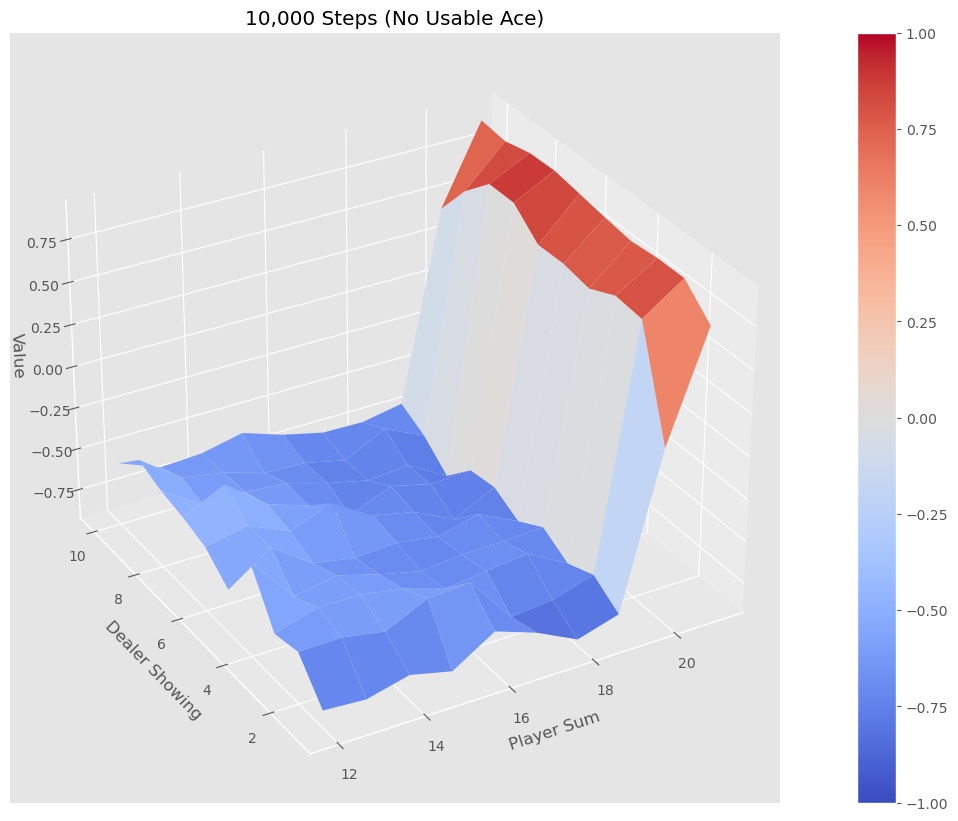

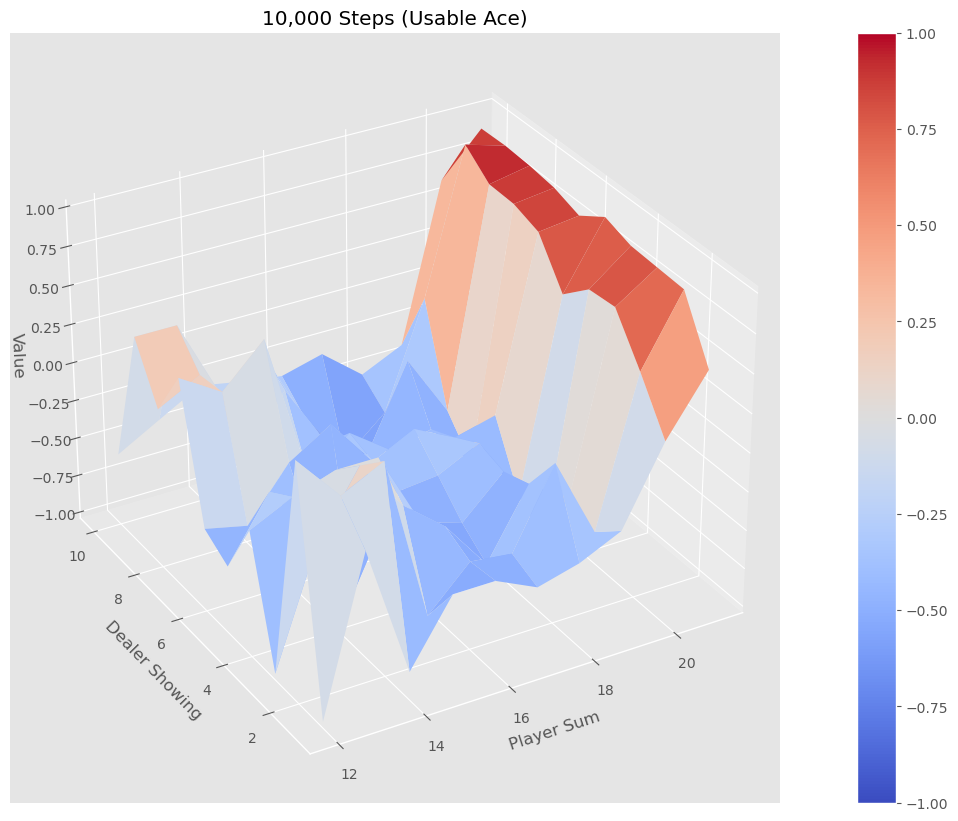

Episode 500000/500000.Method 1 Time: 8.513707503909245
Method 2 Time: 5.153195956256241


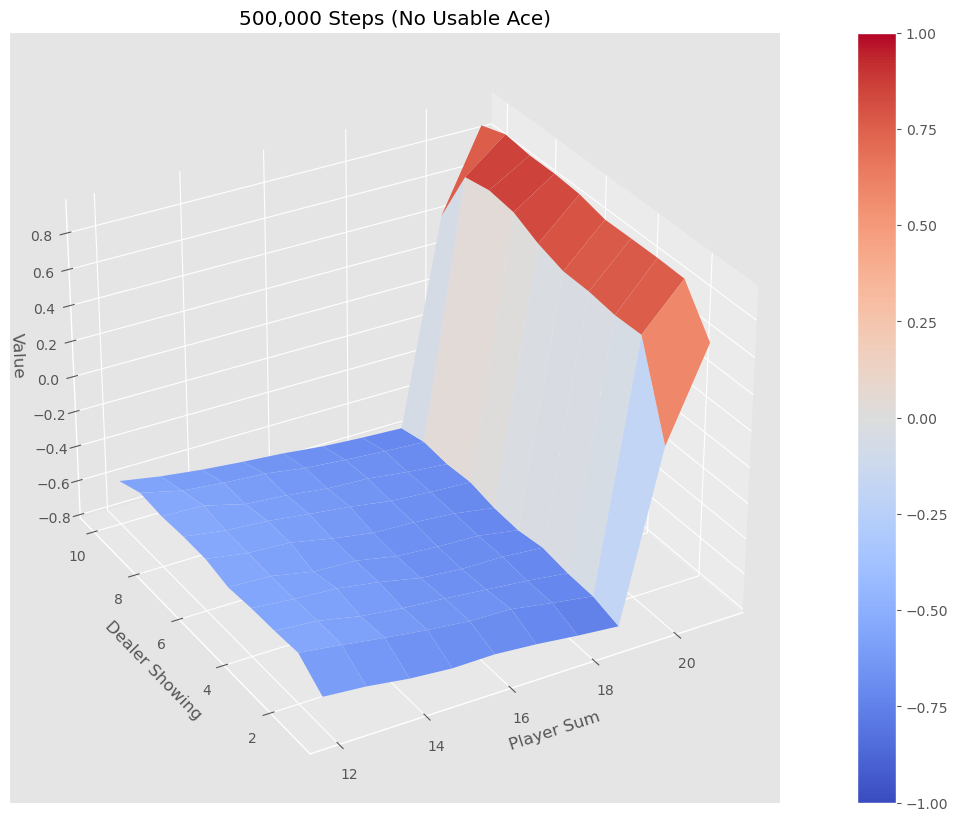

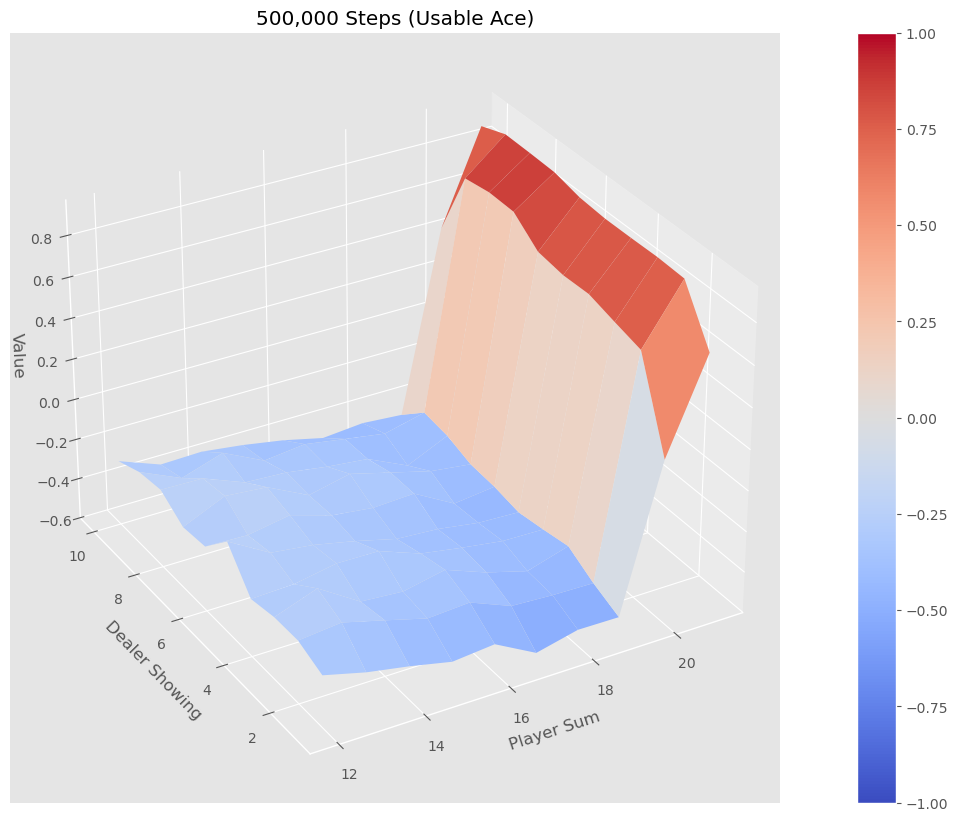

In [21]:
# import time
# start = time.time()
V_10k = mc_prediction(sample_policy, env, num_episodes=10000)
# end = time.time()
# print(f"Time taken for 10,000 episodes: {end - start:.2f} seconds")
plotting.plot_value_function(V_10k, title="10,000 Steps")

# start = time.time()
V_500k = mc_prediction(sample_policy, env, num_episodes=500000)
# end = time.time()
# print(f"Time taken for 500,000 episodes: {end - start:.2f} seconds")
plotting.plot_value_function(V_500k, title="500,000 Steps")